<a href="https://colab.research.google.com/github/lambforwork-source/BTAP-NHOM-5-KHDL/blob/main/KHDL_Nh%C3%B3m_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Đọc dữ liệu
df = pd.read_csv('adult.csv')

# 2. Xử lý giá trị thiếu (thay '?' bằng NaN)
df.replace('?', np.nan, inplace=True)

# Kiểm tra tỉ lệ dữ liệu thiếu
print(df.isnull().sum())

# Xử lý: Vì đây là dữ liệu phân loại, ta có thể dùng Mode (giá trị xuất hiện nhiều nhất)
# hoặc xóa các dòng thiếu nếu tỉ lệ thấp.
df.dropna(inplace=True)

# 3. Chuyển đổi mục tiêu (Income) thành dạng số để dễ phân tích
df['income_bin'] = df['income'].map({'<=50K': 0, '>50K': 1})

age                  0
workclass         1836
fnlwgt               0
education            0
education.num        0
marital.status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital.gain         0
capital.loss         0
hours.per.week       0
native.country     583
income               0
dtype: int64


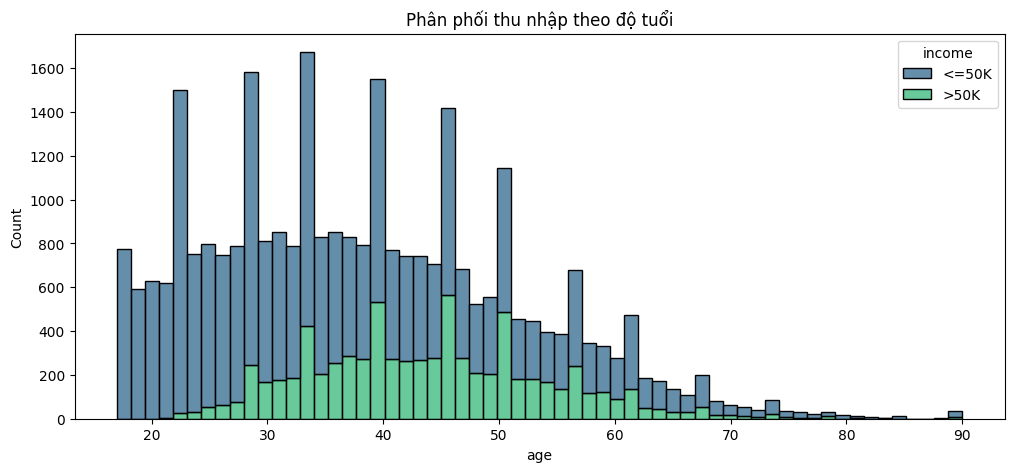

In [3]:
plt.figure(figsize=(12, 5))
sns.histplot(data=df, x='age', hue='income', multiple="stack", palette='viridis')
plt.title('Phân phối thu nhập theo độ tuổi')
plt.show()

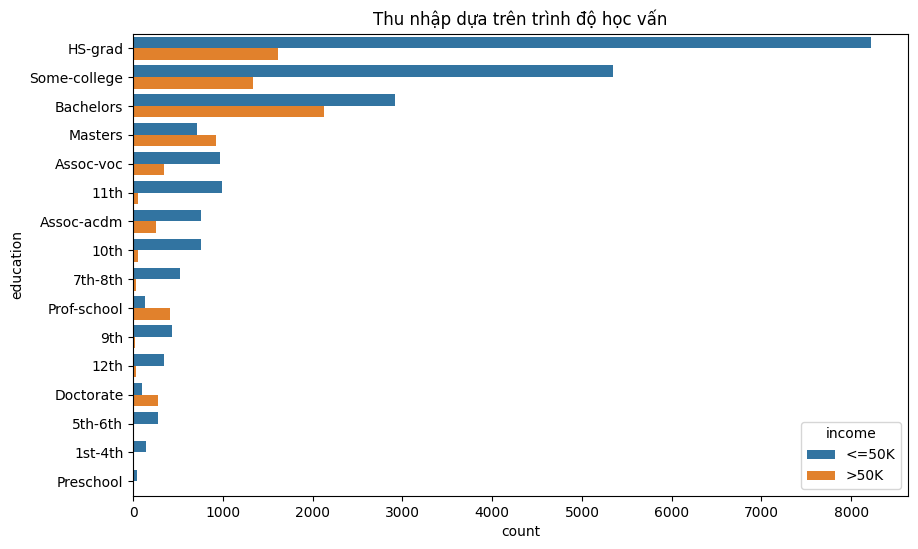

In [4]:
plt.figure(figsize=(10, 6))
sns.countplot(y='education', hue='income', data=df, order=df['education'].value_counts().index)
plt.title('Thu nhập dựa trên trình độ học vấn')
plt.show()


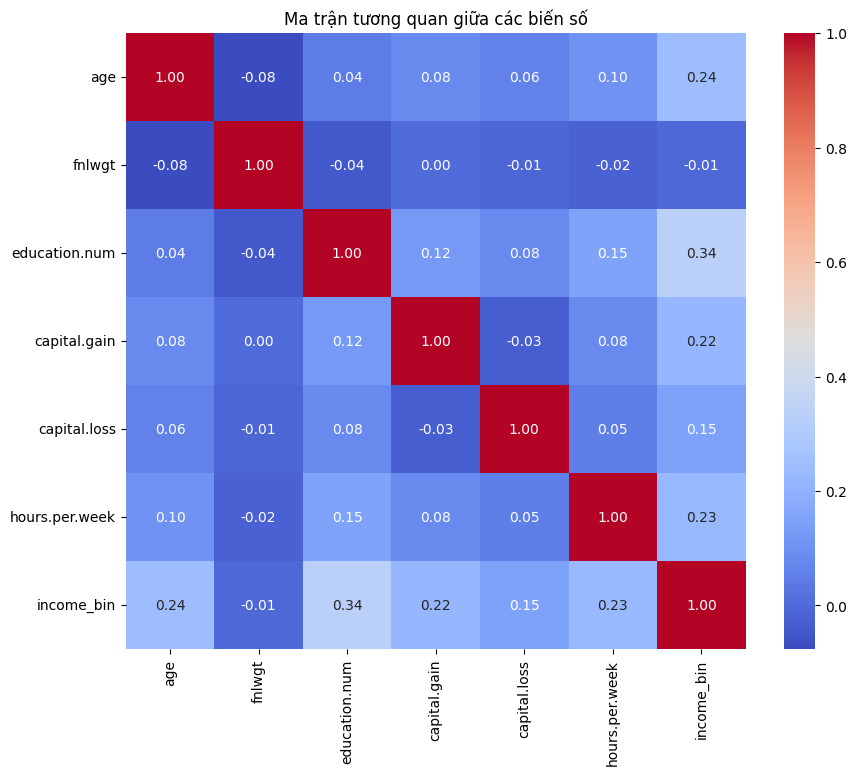

In [7]:
# 1. Hợp nhất các nhóm học vấn (như bạn đã làm)
df['education'] = df['education'].replace(['Preschool', '1st-4th', '5th-6th', '7th-8th', '9th', '10th', '11th', '12th'], 'School')
df['education'] = df['education'].replace(['Assoc-voc', 'Assoc-acdm', 'Prof-school', 'Some-college'], 'Higher-Ed')

# 2. Kiểm tra tương quan - THÊM numeric_only=True để tránh lỗi
plt.figure(figsize=(10, 8))
# Tính toán ma trận tương quan chỉ trên các cột số
corr_matrix = df.corr(numeric_only=True)

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Ma trận tương quan giữa các biến số')
plt.show()